In [16]:
from sympy.abc import x, y
from qldpc import codes
from qldpc.objects import Pauli
from graph_helper_functions import deform_code_for_logical
import numpy as np
import stim
import importlib
import deform_triangular_lattice
importlib.reload(deform_triangular_lattice)

from deform_triangular_lattice import deform_logical_to_tri_lattice

BB_code = codes.BBCode(
            orders={x: 6, y: 6},
            poly_a=x**3 + y + y**2,
            poly_b=y**3 + x + x**2,
        )



In [17]:
# Estimate relative expansion beta_t(G, U) by random sampling.
# G is vertex-by-edge incidence here, so G[S].sum(axis=0) % 2 marks boundary edges.
def estimate_relative_expansion(G, port_rows, samples=50_000, seed=0, t=None):
    rng = np.random.default_rng(seed)
    t = len(port_rows) if t is None else int(t)
    best = np.inf
    for _ in range(samples):
        subset = np.flatnonzero(rng.random(G.shape[0]) < rng.uniform(0.05, 0.5))
        u = np.intersect1d(subset, port_rows).size
        denom = min(t, u, len(port_rows) - u)
        if denom == 0:
            continue
        boundary = np.sum(np.bitwise_xor.reduce(G[subset], axis=0))
        best = min(best, boundary / denom)
    return best

In [10]:
for i in range(12):
    logical = BB_code.get_logical_ops(Pauli.Z)[i]
    deformation_result = deform_code_for_logical(BB_code.matrix, Pauli.Z, logical)
    tri_def = deform_logical_to_tri_lattice(deformation_result=deformation_result, basis=Pauli.Z)
    G = np.asarray(tri_def["auxiliary_graph_incidence_matrix"], dtype=np.uint8) % 2
    vertices = list(map(int, tri_def["auxiliary_graph_incidence_vertices"]))
    vertex_to_row = {q: i for i, q in enumerate(vertices)}

    H_vertex = np.asarray(tri_def["gadget_H_basis"], dtype=np.uint8)
    port_qubits = [
        tri_def["gadget_basis_to_ancilla"][int(r)]
        for r in np.where(np.any(H_vertex[:, :tri_def["n_data"]], axis=1))[0]
    ]
    port_rows = np.asarray([vertex_to_row[int(q)] for q in port_qubits if int(q) in vertex_to_row])

    relative_expansion_estimate = estimate_relative_expansion(G, port_rows, samples=50_000, seed=7)
    print(f"Logical Z{i} estimated relative expansion:", relative_expansion_estimate)


Logical Z0 estimated relative expansion: 1.0
Logical Z1 estimated relative expansion: 2.3333333333333335
Logical Z2 estimated relative expansion: 1.5
Logical Z3 estimated relative expansion: 2.6
Logical Z4 estimated relative expansion: 1.6666666666666667
Logical Z5 estimated relative expansion: 1.875
Logical Z6 estimated relative expansion: 1.3333333333333333
Logical Z7 estimated relative expansion: 1.4
Logical Z8 estimated relative expansion: 1.6666666666666667
Logical Z9 estimated relative expansion: 1.1428571428571428
Logical Z10 estimated relative expansion: 1.0
Logical Z11 estimated relative expansion: 1.4


In [8]:
logical = BB_code.get_logical_ops(Pauli.Z)[9]
deformation_result = deform_code_for_logical(BB_code.matrix, Pauli.Z, logical)
tri_def = deform_logical_to_tri_lattice(deformation_result=deformation_result, basis=Pauli.Z)
G = np.asarray(tri_def["auxiliary_graph_incidence_matrix"], dtype=np.uint8) % 2
vertices = list(map(int, tri_def["auxiliary_graph_incidence_vertices"]))
vertex_to_row = {q: i for i, q in enumerate(vertices)}

H_vertex = np.asarray(tri_def["gadget_H_basis"], dtype=np.uint8)
port_qubits = [
    tri_def["gadget_basis_to_ancilla"][int(r)]
    for r in np.where(np.any(H_vertex[:, :tri_def["n_data"]], axis=1))[0]
]
port_rows = np.asarray([vertex_to_row[int(q)] for q in port_qubits if int(q) in vertex_to_row])

relative_expansion_estimate = estimate_relative_expansion(G, port_rows, samples=50_000, seed=7)
print(f"Logical Z{9} estimated relative expansion:", relative_expansion_estimate)


Logical Z9 estimated relative expansion: 1.1428571428571428


In [15]:
for i in range(12):
    logical = BB_code.get_logical_ops(Pauli.X)[i]
    deformation_result = deform_code_for_logical(BB_code.matrix, Pauli.X, logical)
    tri_def = deform_logical_to_tri_lattice(deformation_result=deformation_result, basis=Pauli.X)
    G = np.asarray(tri_def["auxiliary_graph_incidence_matrix"], dtype=np.uint8) % 2
    vertices = list(map(int, tri_def["auxiliary_graph_incidence_vertices"]))
    vertex_to_row = {q: i for i, q in enumerate(vertices)}

    H_vertex = np.asarray(tri_def["gadget_H_basis"], dtype=np.uint8)
    port_qubits = [
        tri_def["gadget_basis_to_ancilla"][int(r)]
        for r in np.where(np.any(H_vertex[:, :tri_def["n_data"]], axis=1))[0]
    ]
    port_rows = np.asarray([vertex_to_row[int(q)] for q in port_qubits if int(q) in vertex_to_row])

    relative_expansion_estimate = estimate_relative_expansion(G, port_rows, samples=50_000, seed=7)
    print(f"Logical X{i} estimated relative expansion:", relative_expansion_estimate)

Logical X0 estimated relative expansion: 1.3333333333333333
Logical X1 estimated relative expansion: 1.75
Logical X2 estimated relative expansion: 2.0
Logical X3 estimated relative expansion: 3.0
Logical X4 estimated relative expansion: 2.5
Logical X5 estimated relative expansion: 1.0
Logical X6 estimated relative expansion: 2.0
Logical X7 estimated relative expansion: 1.2
Logical X8 estimated relative expansion: 1.0
Logical X9 estimated relative expansion: 1.0
Logical X10 estimated relative expansion: 1.3333333333333333
Logical X11 estimated relative expansion: 1.2


In [18]:
# overhead
for i in range(12):
    logical = BB_code.get_logical_ops(Pauli.Z)[i]
    deformation_result = deform_code_for_logical(BB_code.matrix, Pauli.Z, logical)
    tri_def = deform_logical_to_tri_lattice(deformation_result=deformation_result, basis=Pauli.Z)
    cycles = tri_def["n_cycles"]
    vertices = tri_def["n_vertices"]
    edges = tri_def["n_edges"]
    print(f"Logical Z{i}: ")
    print(f"    cycle count: {cycles}")
    print(f"    edge count: {edges}")
    print(f"    vertex count: {vertices}")


Logical Z0: 
    cycle count: 22
    edge count: 43
    vertex count: 22
Logical Z1: 
    cycle count: 41
    edge count: 74
    vertex count: 34
Logical Z2: 
    cycle count: 32
    edge count: 60
    vertex count: 29
Logical Z3: 
    cycle count: 26
    edge count: 51
    vertex count: 26
Logical Z4: 
    cycle count: 33
    edge count: 64
    vertex count: 32
Logical Z5: 
    cycle count: 36
    edge count: 67
    vertex count: 32
Logical Z6: 
    cycle count: 28
    edge count: 56
    vertex count: 29
Logical Z7: 
    cycle count: 20
    edge count: 39
    vertex count: 20
Logical Z8: 
    cycle count: 30
    edge count: 59
    vertex count: 30
Logical Z9: 
    cycle count: 17
    edge count: 35
    vertex count: 19
Logical Z10: 
    cycle count: 9
    edge count: 22
    vertex count: 14
Logical Z11: 
    cycle count: 17
    edge count: 34
    vertex count: 18


In [20]:
# overhead
for i in range(12):
    logical = BB_code.get_logical_ops(Pauli.X)[i]
    deformation_result = deform_code_for_logical(BB_code.matrix, Pauli.X, logical)
    tri_def = deform_logical_to_tri_lattice(deformation_result=deformation_result, basis=Pauli.X)
    cycles = tri_def["n_cycles"]
    vertices = tri_def["n_vertices"]
    edges = tri_def["n_edges"]
    print(f"Logical X{i}: ")
    print(f"    cycle count: {cycles}")
    print(f"    edge count: {edges}")
    print(f"    vertex count: {vertices}")


Logical X0: 
    cycle count: 13
    edge count: 26
    vertex count: 14
Logical X1: 
    cycle count: 17
    edge count: 32
    vertex count: 16
Logical X2: 
    cycle count: 53
    edge count: 97
    vertex count: 45
Logical X3: 
    cycle count: 62
    edge count: 109
    vertex count: 48
Logical X4: 
    cycle count: 49
    edge count: 86
    vertex count: 38
Logical X5: 
    cycle count: 16
    edge count: 32
    vertex count: 17
Logical X6: 
    cycle count: 40
    edge count: 76
    vertex count: 37
Logical X7: 
    cycle count: 13
    edge count: 30
    vertex count: 18
Logical X8: 
    cycle count: 6
    edge count: 14
    vertex count: 9
Logical X9: 
    cycle count: 15
    edge count: 34
    vertex count: 20
Logical X10: 
    cycle count: 6
    edge count: 14
    vertex count: 9
Logical X11: 
    cycle count: 19
    edge count: 41
    vertex count: 23


In [25]:
for i in range(12):
    logical = BB_code.get_logical_ops(Pauli.X)[i]
    deformation_result = deform_code_for_logical(BB_code.matrix, Pauli.X, logical)
    tri_def = deform_logical_to_tri_lattice(
        deformation_result=deformation_result,
        basis=Pauli.X,
    )

    H_all = np.vstack([
        tri_def["H_basis_def"],
        tri_def["H_opposite_basis_def"],
    ])

    congestion = int(np.max(np.sum(H_all, axis=0)))
    max_stabilizer_weight = int(np.max(np.sum(H_all, axis=1)))

    print(f"Logical X{i}:")
    print(f"    Congestion: {congestion}")
    print(f"    Max stabilizer weight: {max_stabilizer_weight}")


Logical X0:
    Congestion: 7
    Max stabilizer weight: 9
Logical X1:
    Congestion: 7
    Max stabilizer weight: 8
Logical X2:
    Congestion: 7
    Max stabilizer weight: 10
Logical X3:
    Congestion: 7
    Max stabilizer weight: 13
Logical X4:
    Congestion: 7
    Max stabilizer weight: 10
Logical X5:
    Congestion: 7
    Max stabilizer weight: 10
Logical X6:
    Congestion: 7
    Max stabilizer weight: 11
Logical X7:
    Congestion: 7
    Max stabilizer weight: 9
Logical X8:
    Congestion: 7
    Max stabilizer weight: 8
Logical X9:
    Congestion: 7
    Max stabilizer weight: 9
Logical X10:
    Congestion: 7
    Max stabilizer weight: 8
Logical X11:
    Congestion: 7
    Max stabilizer weight: 9


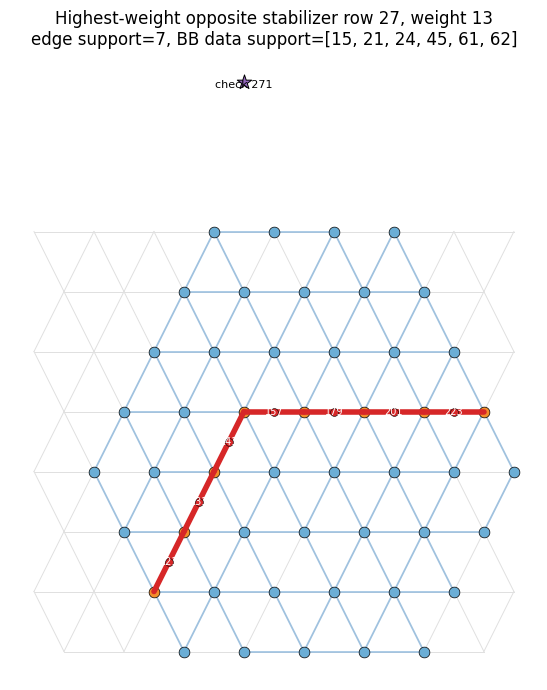

In [39]:
import importlib
import deform_triangular_lattice
importlib.reload(deform_triangular_lattice)

from deform_triangular_lattice import (
    deform_logical_to_tri_lattice,
    plot_highest_weight_stabilizer,
)

logical = BB_code.get_logical_ops(Pauli.X)[3]
deformation_result = deform_code_for_logical(BB_code.matrix, Pauli.X, logical)

tri_def = deform_logical_to_tri_lattice(
    deformation_result,
    basis=Pauli.X,
)

fig, ax, info = plot_highest_weight_stabilizer(tri_def)